##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

# Step 1 — Install libraries

In [1]:
!pip install keras-hub -q

# Step 2 — Import libraries

In [2]:
import keras
import keras_hub
import numpy as np
import requests
from PIL import Image
import matplotlib.pyplot as plt

# Step 3 — Download ImageNet class names (TEXT FILE)

In [3]:
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

labels = requests.get(url).text.split("\n")

print("Total classes:", len(labels))
print(labels[:10])

Total classes: 1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


# Step 4 — Load ViT Preprocessor

In [4]:
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)


100%|██████████| 593/593 [00:00<00:00, 391kB/s]


100%|██████████| 1.65k/1.65k [00:00<00:00, 1.87MB/s]


# Step 5 — Load ViT Model

In [9]:
model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet"
)
preprocessor=preprocessor

# Step 6 — Download 5 test images

In [28]:
from google.colab import files
uploaded = files.upload()

print("Uploaded files:", list(uploaded.keys()))

# Save uploaded files to /content/ directory
for filename, content in uploaded.items():
    with open(f"/content/{filename}", "wb") as f:
        f.write(content)
    print(f"Saved /content/{filename}")

Saving Giraffa_camelopardalis_reticulata_01,_flip.jpg to Giraffa_camelopardalis_reticulata_01,_flip.jpg
Saving ferrari-e-suv-2-copy-680287cac36b2.avif to ferrari-e-suv-2-copy-680287cac36b2.avif
Saving images (2).jpeg to images (2).jpeg
Saving images.webp to images.webp
Saving dog-puppy-on-garden-royalty-free-image-1586966191.avif to dog-puppy-on-garden-royalty-free-image-1586966191.avif
Uploaded files: ['Giraffa_camelopardalis_reticulata_01,_flip.jpg', 'ferrari-e-suv-2-copy-680287cac36b2.avif', 'images (2).jpeg', 'images.webp', 'dog-puppy-on-garden-royalty-free-image-1586966191.avif']
Saved /content/Giraffa_camelopardalis_reticulata_01,_flip.jpg
Saved /content/ferrari-e-suv-2-copy-680287cac36b2.avif
Saved /content/images (2).jpeg
Saved /content/images.webp
Saved /content/dog-puppy-on-garden-royalty-free-image-1586966191.avif


# Step 7 — Predict classes

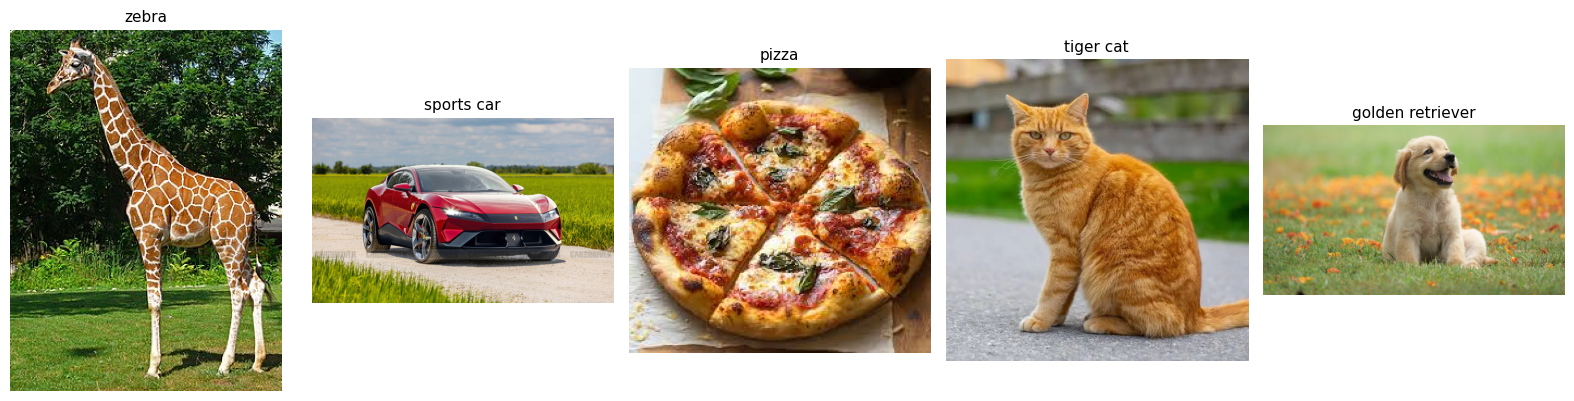

,Image File,Predicted Label,True Label,Correct
0,giraffe.jpg,zebra,giraffe,No
1,sports_car.jpg,sports car,sports car,Yes
2,pizza.jpg,pizza,pizza,Yes
3,tiger_cat.jpg,tiger cat,tiger cat,Yes
4,golden_retriever.jpg,golden retriever,golden retriever,Yes


In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import keras

# Desired file names
target_names = [
    "giraffe.jpg",
    "sports_car.jpg",
    "pizza.jpg",
    "tiger_cat.jpg",
    "golden_retriever.jpg"
]

# Rename uploaded files only if needed
for old_name, target_name in zip(uploaded.keys(), target_names):
    if old_name != target_name:
        os.rename(f"/content/{old_name}", f"/content/{target_name}")

# Image files and true labels
image_files = target_names

true_labels = [
    "giraffe",
    "sports car",
    "pizza",
    "tiger cat",
    "golden retriever"
]

results = []
images = []
predicted_labels = []

# Prediction loop
for i, file_name in enumerate(image_files):

    img = Image.open(f"/content/{file_name}").convert("RGB")
    img_np = np.array(img)

    images.append(img)

    batch = np.expand_dims(img_np, axis=0)

    preds = model.predict(batch, verbose=0)
    probs = keras.activations.softmax(preds, axis=-1).numpy()

    pred_index = int(np.argmax(probs))
    predicted_label = labels[pred_index]

    predicted_labels.append(predicted_label)

    true = true_labels[i].lower()
    correct = "Yes" if true in predicted_label.lower() else "No"

    results.append([file_name, predicted_label, true_labels[i], correct])


# Show images side by side with prediction above each image
plt.figure(figsize=(16,4))

for i, img in enumerate(images):
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(predicted_labels[i], fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.show()


# Clean results table
df = pd.DataFrame(
    results,
    columns=["Image File", "Predicted Label", "True Label", "Correct"]
)

display(df)


### Record Your Results

| Image File | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
|------------|----------------|---------------------------------|-------------------|
| giraffe.jpg | zebra | giraffe | No |
| sports_car.jpg | sports car | sports car | Yes |
| pizza.jpg | pizza | pizza | Yes |
| tiger_cat.jpg | tiger cat | tiger cat | Yes |
| golden_retriever.jpg | golden retriever | golden retriever | Yes |